In [1]:
## importing packages ##
import numpy as np
import pandas as pd

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline
import re
from imp import reload

from bs4 import BeautifulSoup as bs
import requests


import string
import nltk
from nltk.stem import WordNetLemmatizer 
from nltk.corpus import stopwords,wordnet 
from wordcloud import WordCloud
# nltk.download('averaged_perceptron_tagger')
# nltk.download('vader_lexicon')
# nltk.download('wordnet')

from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.sklearn
pyLDAvis.enable_notebook()


import warnings
warnings.filterwarnings("ignore")

C:\Users\kavia\AppData\Local\Temp\ipykernel_27884\2977375178.py:10: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  from imp import reload


In [2]:
tesla = pd.read_csv('../preprocesseddata/tesla.csv')

In [3]:
# from https://medium.com/swlh/sentiment-analysis-topic-modeling-for-hotel-reviews-6b83653f5b08

#Create a function to build the optimal LDA model
def optimal_lda_model(df_tweets, tweets_colname, stop_words):
    '''
    INPUTS:
        df_review - dataframe that contains the reviews
        review_colname: name of column that contains reviews
        
    OUTPUTS:
        lda_tfidf - Latent Dirichlet Allocation (LDA) model
        dtm_tfidf - document-term matrix in the tfidf format
        tfidf_vectorizer - word frequency in the reviews
        A graph comparing LDA Model Performance Scores with different params
    '''
    docs_raw = df_tweets[tweets_colname].tolist()

    #************   Step 1: Convert to document-term matrix   ************#

    # Transform text to vector form using the vectorizer object
    tf_vectorizer = CountVectorizer(stop_words = ['english'] + stop_words,
                                    lowercase = True,
                                    ngram_range=(1, 2),
                                    # token_pattern = r'\b[a-zA-Z]{3,}\b', # num chars > 3 to avoid some meaningless words
                                    min_df = 10)                         # discard words that appear in < 10 tweets    

    #apply transformation
    tfidf_vectorizer = TfidfVectorizer(**tf_vectorizer.get_params())

    #convert to document-term matrix
    dtm_tfidf = tfidf_vectorizer.fit_transform(docs_raw)  

    print(f"The shape of the tfidf is {dtm_tfidf.shape}, meaning that there are {dtm_tfidf.shape[0]} {tweets_colname} and {dtm_tfidf.shape[1]} tokens made through the filtering process.")



    #*******   Step 2: GridSearch & parameter tuning to find the optimal LDA model   *******#

    # Define Search Param
    search_params = {'n_components': [5, 10], 
                     'learning_decay': [.5, .7]}

    # Init the Model
    lda = LatentDirichletAllocation()

    # Init Grid Search Class
    model = GridSearchCV(lda, param_grid=search_params)

    # Do the Grid Search
    model.fit(dtm_tfidf)


    #*****  Step 3: Output the optimal lda model and its parameters  *****#

    # Best Model
    best_lda_model = model.best_estimator_

    # Model Parameters
    print("Best Model's Params: ", model.best_params_)

    # Log Likelihood Score: Higher the better
    print("Model Log Likelihood Score: ", model.best_score_)

    # Perplexity: Lower the better. Perplexity = exp(-1. * log-likelihood per word)
    print("Model Perplexity: ", best_lda_model.perplexity(dtm_tfidf))


    #***********   Step 4: Compare LDA Model Performance Scores   ***********#

    #Get Log Likelyhoods from Grid Search Output
    gscore=model.fit(dtm_tfidf).cv_results_
    n_topics = [5, 10]

    log_likelyhoods_5 = [gscore['mean_test_score'][gscore['params'].index(v)] for v in gscore['params'] if v['learning_decay']==0.5]
    log_likelyhoods_7 = [gscore['mean_test_score'][gscore['params'].index(v)] for v in gscore['params'] if v['learning_decay']==0.7]

    # Show graph
    plt.figure(figsize=(12, 8))
    plt.plot(n_topics, log_likelyhoods_5, label='0.5')
    plt.plot(n_topics, log_likelyhoods_7, label='0.7')
    plt.title("Choosing Optimal LDA Model")
    plt.xlabel("Num Topics")
    plt.ylabel("Log Likelyhood Scores")
    plt.legend(title='Learning decay', loc='best')
    plt.show()

    return best_lda_model, dtm_tfidf, tfidf_vectorizer


In [4]:
# Add my own words to the stop_words
tesla_stop_words = ['@user', '@http', 'user', 'http','https', 'ev', 'electric', 'car', 'cars',
                   'the', 'to', 'is', 'of', 'with', 'in', 'an', 'and', 'on', 
                   'this', 'that', 'it', 'for', 'are', 'you', 'all']

The shape of the tfidf is (111740, 33260), meaning that there are 111740 Text and 33260 tokens made through the filtering process.
Best Model's Params:  {'learning_decay': 0.7, 'n_components': 5}
Model Log Likelihood Score:  -1150226.7804806978
Model Perplexity:  13171.840349645594


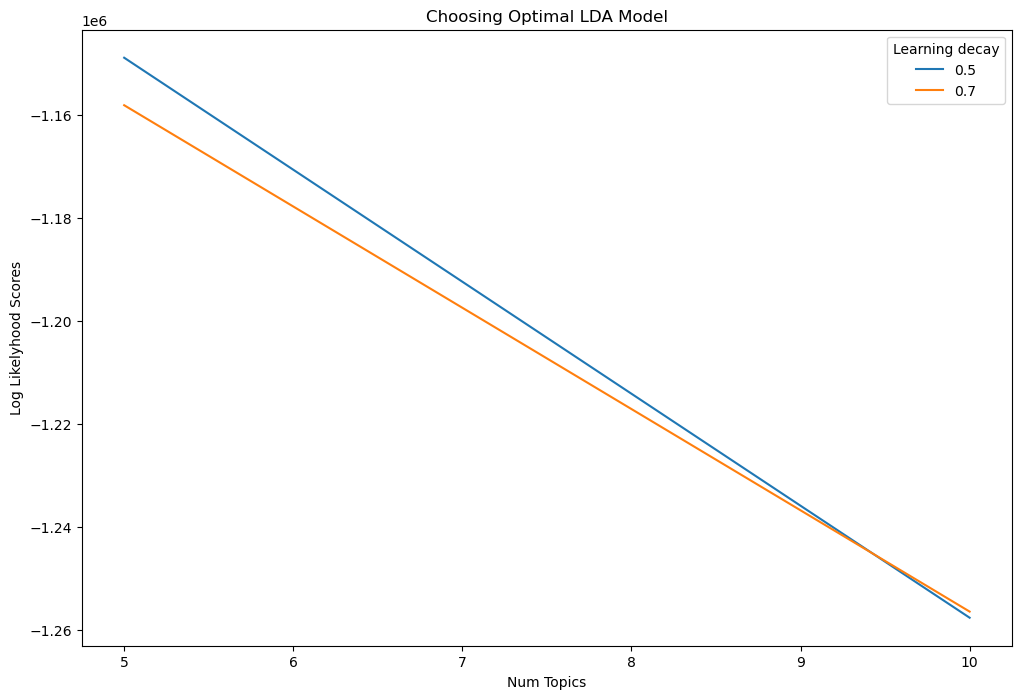

In [5]:
best_lda_model, dtm_tfidf, tfidf_vectorizer = optimal_lda_model(tesla, 'Text', tesla_stop_words)

In [6]:
#Create a function to inspect the topics we created 
def display_topics(model, feature_names, n_top_words):
    '''
    INPUTS:
        model - the model we created
        feature_names - tells us what word each column in the matric represents
        n_top_words - number of top words to display
    OUTPUTS:
        a dataframe that contains the topics we created and the weights of each token
    '''
    topic_dict = {}
    for topic_idx, topic in enumerate(model.components_):
        topic_dict[f"Topic {topic_idx+1} words"] = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topic_dict[f"Topic {topic_idx+1} weights"] = [f'{topic[i]:.1f}' for i in topic.argsort()[:-n_top_words - 1:-1]]

    return pd.DataFrame(topic_dict)


display_topics(best_lda_model, tfidf_vectorizer.get_feature_names(), n_top_words = 10)

,Topic 1 words,Topic 1 weights,Topic 2 words,Topic 2 weights,Topic 3 words,Topic 3 weights,Topic 4 words,Topic 4 weights,Topic 5 words,Topic 5 weights
0,model,528.9,interior,566.5,model,2804.4,tesla,503.2,model,1155.6
1,tesla,503.1,long range,556.9,tesla,2139.4,bmw,408.7,tesla,782.2
2,tesla model,345.7,long,521.9,tesla model,1592.7,electricvehicles,358.4,tesla model,740.0
3,prices,298.5,range,505.3,my,1549.5,tesla model,335.6,model model,501.6
4,model model,291.4,co,425.0,have,1133.2,model,318.9,first,360.7
5,000,197.5,model long,366.7,but,1016.6,vw,307.0,days,326.1
6,has,183.8,black,359.7,be,1003.2,evs,262.9,norway,320.2
7,new,175.4,model,353.7,or,909.9,mercedes,262.2,first tesla,296.9
8,by,169.2,wheels,313.8,will,861.7,electriccars,261.8,left,287.4
9,price,162.2,seat,307.8,can,852.5,electriccar,241.6,buy my,283.4


In [7]:
# Topic Modelling Visualization for the Negative Reviews
pyLDAvis.sklearn.prepare(best_lda_model, dtm_tfidf, tfidf_vectorizer)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.100894 -0.026556       1        1  51.876520
4     -0.051757 -0.203484       2        1  12.617754
1      0.326741  0.016648       3        1  12.245206
3     -0.087574  0.178371       4        1  11.774631
0     -0.086517  0.035021       5        1  11.485889, topic_info=             Term         Freq        Total Category  logprob  loglift
17366       model  4834.000000  4834.000000  Default  30.0000  30.0000
15999  long range   598.000000   598.000000  Default  29.0000  29.0000
27675       tesla  3971.000000  3971.000000  Default  28.0000  28.0000
14297    interior   705.000000   705.000000  Default  27.0000  27.0000
15986        long   681.000000   681.000000  Default  26.0000  26.0000
...           ...          ...          ...      ...      ...      ...
29945        tsla   100.506125   578.101888   Topic5  -6.3678   0.4145
14781        just    98.920922   772.410977   Topic5  -6.3837   0.1089
30856    vehicles    96.009886   588.915436   Topic5  -6.4135   0.3502
4902          bmw    94.728972   812.665492   Topic5  -6.4270   0.0148
22133       plaid    95.197342  1029.527815   Topic5  -6.4220  -0.2169

[334 rows x 6 columns], token_table=       Topic      Freq      Term
term                            
7          1  0.133712       000
7          2  0.066121       000
7          3  0.223343       000
7          4  0.283587       000
7          5  0.295342       000
...      ...       ...       ...
32791      5  0.005022  would be
33135      1  0.922292      your
33135      2  0.030327      your
33135      4  0.008920      your
33135      5  0.035679      your

[659 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 5, 2, 4, 1])

We can pick three main topics for the tesla data:
- price
- range
- models

In [11]:
p = pyLDAvis.sklearn.prepare(best_lda_model, dtm_tfidf, tfidf_vectorizer)
pyLDAvis.save_html(p, '../links/tesla_topic_modeling.html')